# NumCompute-Stream: Streaming Demo

This notebook walks through a complete streaming machine learning workflow,
built with **NumCompute-Stream** using nothing but NumPy and matplotlib.

The idea is to treat data as it arrives rather than all at once. We start by
loading a dataset from CSV with our custom `io.py` loader, then break it into
chunks to mimic a live data stream. From there, a `Pipeline` (Imputer →
StandardScaler → RandomForest) learns incrementally, calling `partial_fit`
on each chunk as it comes in and following the prequential "test then train"
protocol that `StreamTrainer` handles for us.

Finally, we track how the model does over time, logging and plotting metrics
with `visualise.py`, and see how the ensemble stacks up against a plain
single decision tree.

In [10]:
import os, sys
import numpy as np


sys.path.insert(0, os.path.abspath(".."))

from numcompute_stream.io import load_csv, iter_chunks
from numcompute_stream.pipeline import Pipeline
from numcompute_stream.preprocessing import Imputer, StandardScaler
from numcompute_stream.ensemble import RandomForestClassifier
from numcompute_stream.tree import DecisionTreeClassifier
from numcompute_stream.stream import StreamTrainer
from numcompute_stream.metrics import F1Score, ConfusionMatrix
from numcompute_stream import visualise as viz

%matplotlib inline

## 1. Load the dataset

`load_csv` auto-detects numeric vs. categorical columns, integer-encodes the
categoricals, and converts blank/`NA` cells to `NaN` so the `Imputer` can fill
them downstream. The synthetic `stream_data.csv` has 8000 rows, four numeric
features, one categorical (`region`), a binary `label`, and ~2% missing values.

In [2]:

if not os.path.exists("stream_data.csv"):
    import make_dataset; make_dataset.main()

data = load_csv("stream_data.csv", target="label")
X, y = data["X"], data["y"].astype(int)
classes = np.unique(y)

print("feature names :", data["feature_names"])
print("X shape       :", X.shape)
print("missing cells :", int(np.isnan(X).sum()))
print("class balance :", {int(c): int((y == c).sum()) for c in classes})

feature names : ['age', 'income', 'score', 'balance', 'region']
X shape       : (8000, 5)
missing cells : 302
class balance : {0: 3971, 1: 4029}


## 2. Simulate a stream

`iter_chunks` yields successive `(X_chunk, y_chunk)` slices. Each chunk plays the
role of a freshly arriving mini-batch in an online setting.

In [9]:
N_CHUNKS = 20
chunk_sizes = [len(yc) for _, yc in iter_chunks(X, y, n_chunks=N_CHUNKS)]
print(f"{N_CHUNKS} chunks, ~{chunk_sizes[0]} samples each")

20 chunks, ~400 samples each


## 3. Incremental training with a Pipeline

Both models share the same preprocessing pipeline. Since every component
implements the same `partial_fit`/`transform` interface, the `Pipeline` can
thread each chunk through the imputer and scaler, which update their running
statistics as data flows through, before it ever reaches the estimator. There's
no special casing needed anywhere.

`StreamTrainer` takes care of the prequential protocol: for each chunk it
predicts first, scoring itself on data it hasn't seen yet, and only then trains
on it. Testing before training like this gives you an honest running estimate
of how well the model actually generalises.

In [5]:
def make_pipeline(model):
    return Pipeline([
        ("impute", Imputer(strategy="mean")),
        ("scale",  StandardScaler()),
        ("model",  model),
    ])

rf_trainer = StreamTrainer(
    make_pipeline(RandomForestClassifier(
        n_estimators=20, max_depth=10, random_state=0, max_buffer=3000)),
    metrics={"f1": F1Score(labels=classes.tolist(), average="macro")})

tree_trainer = StreamTrainer(
    make_pipeline(DecisionTreeClassifier(max_depth=10, max_buffer=3000)),
    metrics={"f1": F1Score(labels=classes.tolist(), average="macro")})

for Xc, yc in iter_chunks(X, y, n_chunks=N_CHUNKS):
    rf_trainer.fit_chunk(Xc, yc, classes=classes)
    tree_trainer.fit_chunk(Xc, yc, classes=classes)

rf_log, tree_log = rf_trainer.log_, tree_trainer.log_
print(f"Random forest : cum.acc={rf_log['cumulative_accuracy'][-1]:.4f}  "
      f"macroF1={rf_log['f1'][-1]:.4f}")
print(f"Single tree   : cum.acc={tree_log['cumulative_accuracy'][-1]:.4f}  "
      f"macroF1={tree_log['f1'][-1]:.4f}")

Random forest : cum.acc=0.8078  macroF1=0.8077
Single tree   : cum.acc=0.7496  macroF1=0.7496


## 4. Visualise metrics over time

`compare_models` overlays the cumulative accuracy of both models. The random
forest's cumulative accuracy converges higher and more smoothly than the
single tree's as it sees more of the stream.

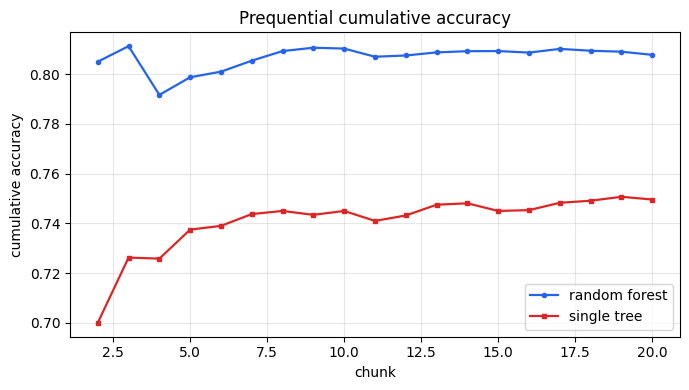

<Axes: title={'center': 'Prequential cumulative accuracy'}, xlabel='chunk', ylabel='cumulative accuracy'>

In [6]:

viz.compare_models(
    rf_log["cumulative_accuracy"], tree_log["cumulative_accuracy"],
    labels=("random forest", "single tree"),
    title="Prequential cumulative accuracy",
    ylabel="cumulative accuracy", show=True)

### Ensemble vs. single tree

`compare_models` overlays the per-chunk accuracy of both models. The forest's
bagging + feature subsampling reduces variance, so it tracks consistently above
the single tree.

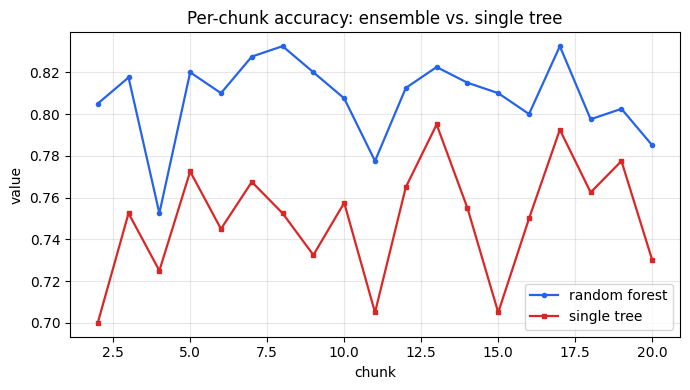

<Axes: title={'center': 'Per-chunk accuracy: ensemble vs. single tree'}, xlabel='chunk', ylabel='value'>

In [8]:
viz.compare_models(
    rf_log["chunk_accuracy"], tree_log["chunk_accuracy"],
    labels=("random forest", "single tree"),
    title="Per-chunk accuracy: ensemble vs. single tree", show=True)

### Predictions on the latest chunk

Finally we inspect predictions vs. ground truth and the confusion matrix on the
most recent chunk.

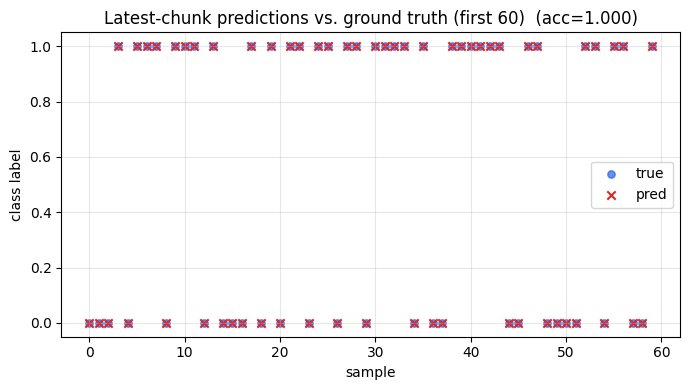

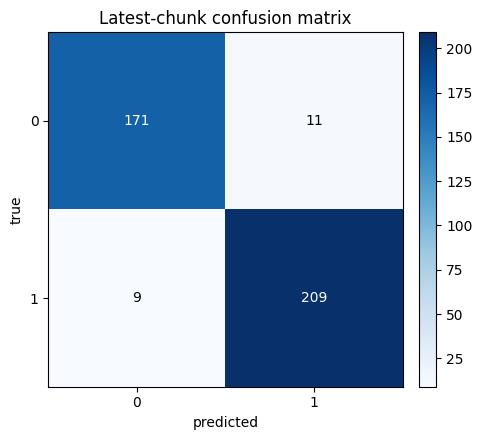

<Axes: title={'center': 'Latest-chunk confusion matrix'}, xlabel='predicted', ylabel='true'>

In [7]:
Xc, yc = list(iter_chunks(X, y, n_chunks=N_CHUNKS))[-1]
y_pred = rf_trainer.model.predict(Xc)

viz.plot_predictions_vs_ground_truth(
    yc[:60], y_pred[:60],
    title="Latest-chunk predictions vs. ground truth (first 60)", show=True)

cm = ConfusionMatrix(labels=classes.tolist())
cm.update(yc, y_pred)
viz.plot_confusion_matrix(cm.result(), labels=classes.tolist(),
                          title="Latest-chunk confusion matrix", show=True)

## Summary

Using only NumPy and matplotlib we streamed a dataset chunk-by-chunk through a
shared preprocessing pipeline, trained both a single tree and a random forest
incrementally with `partial_fit`, evaluated them prequentially, and visualised
accuracy, memory and predictions over time. The ensemble's variance reduction
gives it a clear and consistent edge over the single tree.